# IPAD Cycle-Aware SubspaceAD 실험 기록

Frozen baseline → 정상 LoRA 채택 → C/P ablation. 실행된 결과만 표시합니다.

## 설정과 실행

기본값은 분석 전용입니다. 학습 실행 시 RUN_STAGES에 원하는 단계를 넣습니다.

In [1]:
from pathlib import Path
import sys, subprocess, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/'configs').exists() else Path.cwd().parent
DATA_ROOT = ROOT.parent/'IPAD_dataset'
RUN_STAGES = []
for stage in RUN_STAGES:
    subprocess.run([sys.executable, '-m', 'ipad_experiment.pipeline', stage, '--data-root', str(DATA_ROOT)], cwd=ROOT, check=True)
print('Experiment root:', ROOT.name)

Experiment root: experiment


## 데이터와 규약

분할·제외 목록은 성능 계산 전에 고정합니다. 녹화 그룹과 실제 주기 경계는 미확인입니다.

In [2]:
display(pd.read_csv(ROOT/'results/00_prepare/data_counts.csv'))
display(pd.read_csv(ROOT/'results/00_prepare/exclusions.csv'))

,scene,partition,videos,frames
0,R01,final,9,2339
1,R01,development,6,1346
2,R01,validation,5,1125
3,R01,threshold,5,1144
4,R01,reference,5,1133
5,R01,fit,19,4406
6,R02,development,5,3209
7,R02,final,7,4497
8,R02,fit,17,10117
9,R02,threshold,4,2374


,id,frames,label_frames,reason
0,R02/testing/12,806,805,unresolved_frame_label_length_mismatch
1,R02/testing/13,609,608,unresolved_frame_label_length_mismatch
2,R02/testing/14,497,498,unresolved_frame_label_length_mismatch


## 실행 결과와 시각자료

개발셋과 최종셋은 별도 표기합니다. 미실행 결과를 수치로 채우지 않습니다.

00_prepare
No performance metrics for this stage.


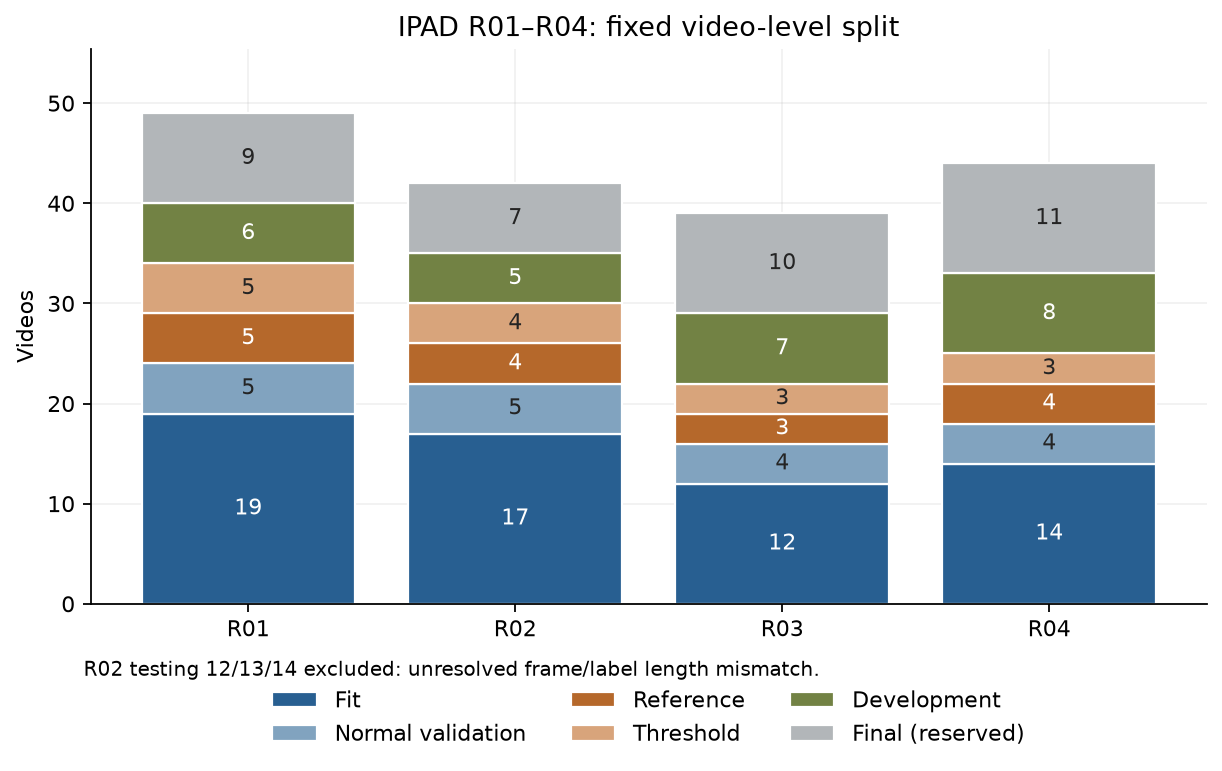

01_baseline


,scene,seed,branch,partition,threshold,auroc,ap,f1,tpr,fpr,frames,positive_frames,events,detected_events,event_coverage,delay_sum,mean_detected_event_delay_frames
0,R01,42,S,development,4.730921,0.656673,0.490963,0.183306,0.110891,0.059453,1346,505,3,3,1.000000,123,41.00
1,R02,42,S,development,4.394875,0.808093,0.664571,0.043518,0.022599,0.007918,3209,1062,5,2,0.400000,0,0.00
2,R03,42,S,development,2.242599,0.729861,0.768509,0.466371,0.307242,0.008880,4813,2223,6,4,0.666667,335,83.75
3,R04,42,S,development,13.199401,0.730513,0.594498,0.000000,0.000000,0.004705,3586,1673,13,0,0.000000,0,NaN


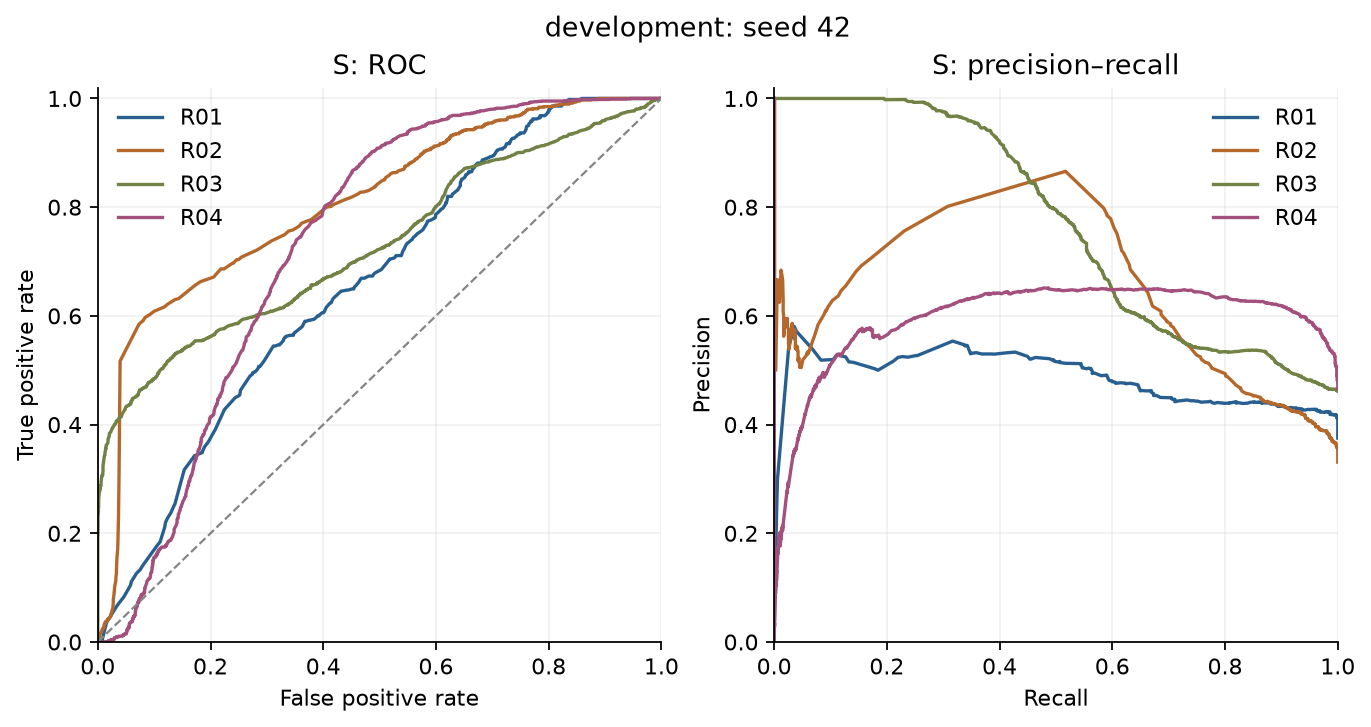

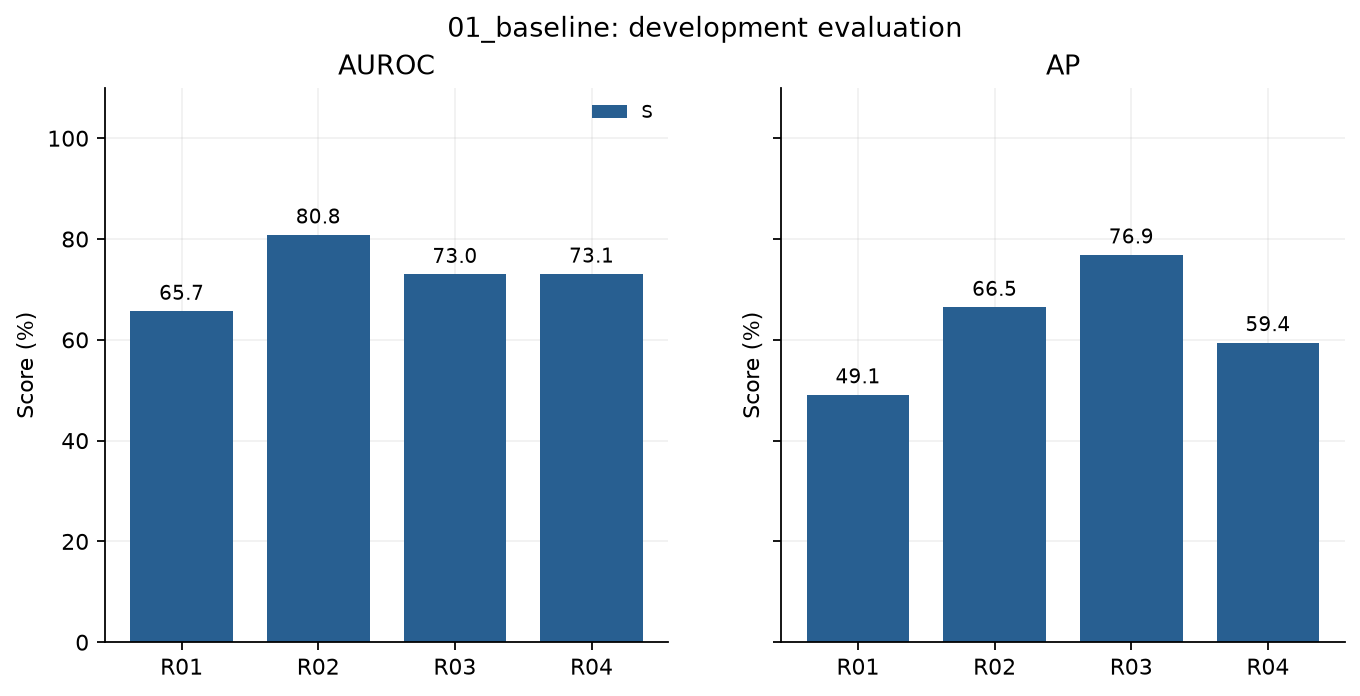

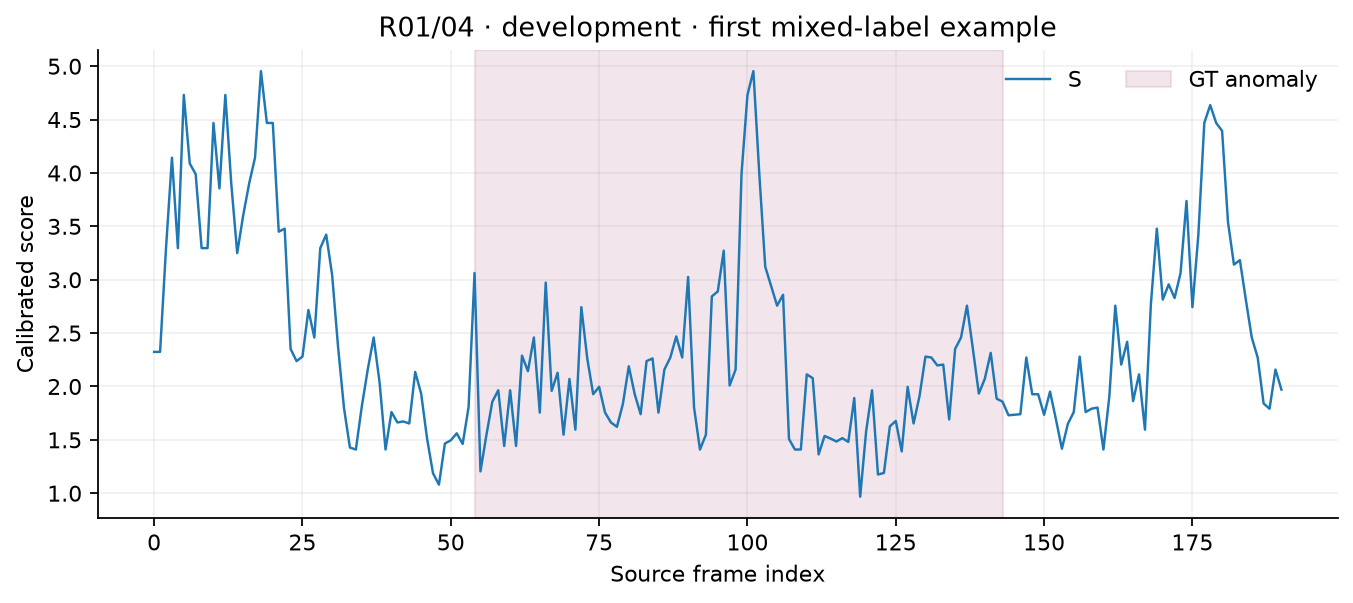

02_lora


,scene,seed,branch,partition,threshold,auroc,ap,f1,tpr,fpr,frames,positive_frames,events,detected_events,event_coverage,delay_sum,mean_detected_event_delay_frames
0,R01,42,S,development,4.836282,0.658052,0.497853,0.215289,0.136634,0.079667,1346,505,3,2,0.666667,46,23.00
1,R01,43,S,development,4.730921,0.649652,0.488149,0.207874,0.130693,0.076100,1346,505,3,2,0.666667,47,23.50
2,R01,44,S,development,4.836282,0.641618,0.481780,0.207221,0.130693,0.078478,1346,505,3,2,0.666667,47,23.50
3,R02,42,S,development,4.328183,0.809202,0.670153,0.043478,0.022599,0.008384,3209,1062,5,2,0.400000,0,0.00
4,R02,43,S,development,4.360973,0.808457,0.670359,0.043478,0.022599,0.008384,3209,1062,5,2,0.400000,0,0.00
5,R02,44,S,development,4.360973,0.811572,0.671875,0.043478,0.022599,0.008384,3209,1062,5,2,0.400000,0,0.00
6,R03,42,S,development,2.260537,0.729954,0.768885,0.467532,0.307692,0.007336,4813,2223,6,4,0.666667,565,141.25
7,R03,43,S,development,2.242599,0.730392,0.769799,0.469304,0.309492,0.008108,4813,2223,6,4,0.666667,565,141.25
8,R03,44,S,development,2.220620,0.730131,0.769548,0.475025,0.314440,0.008108,4813,2223,6,4,0.666667,565,141.25
9,R04,42,S,development,12.881333,0.729881,0.594865,0.000000,0.000000,0.005227,3586,1673,13,0,0.000000,0,NaN


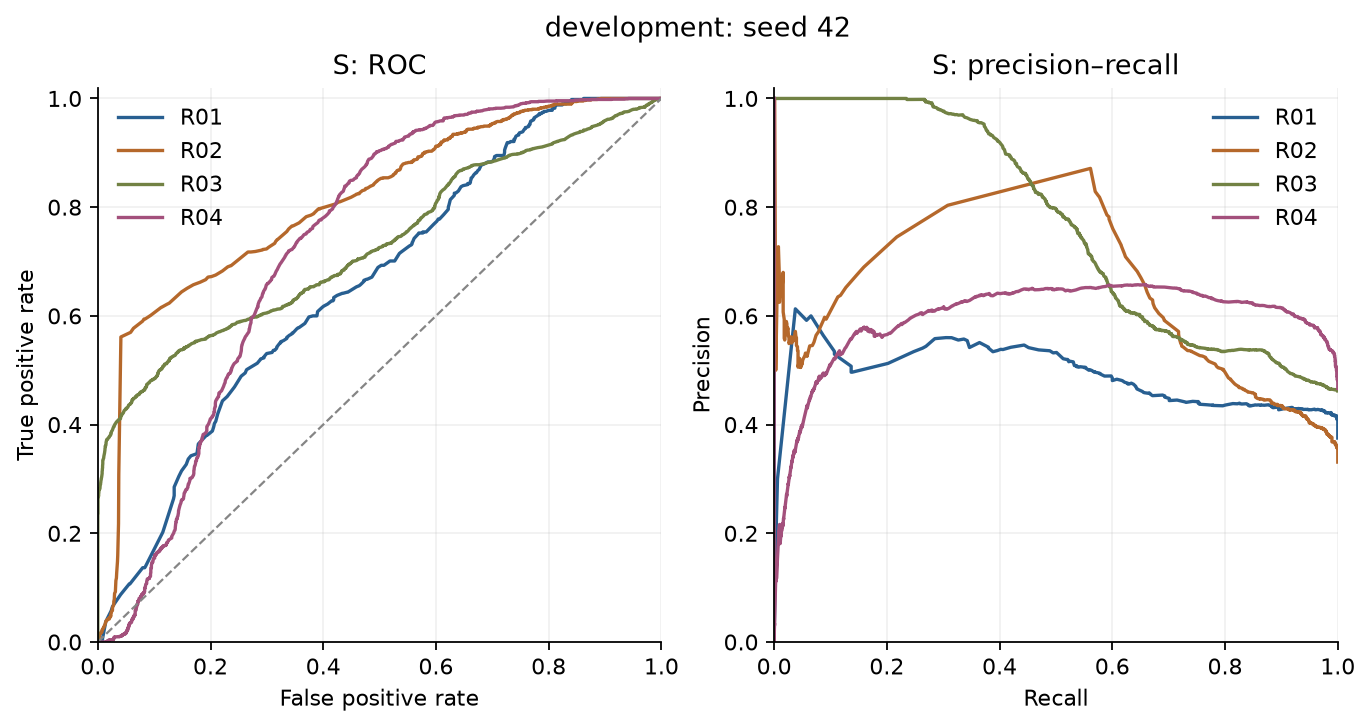

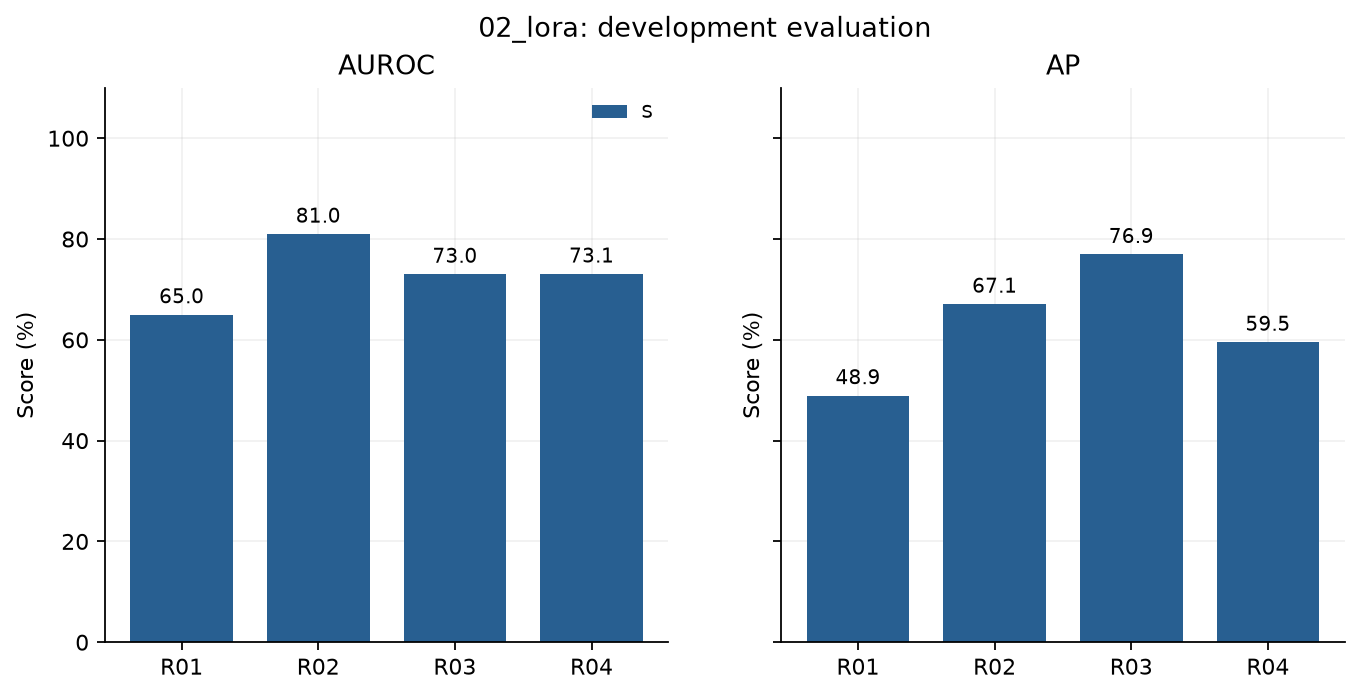

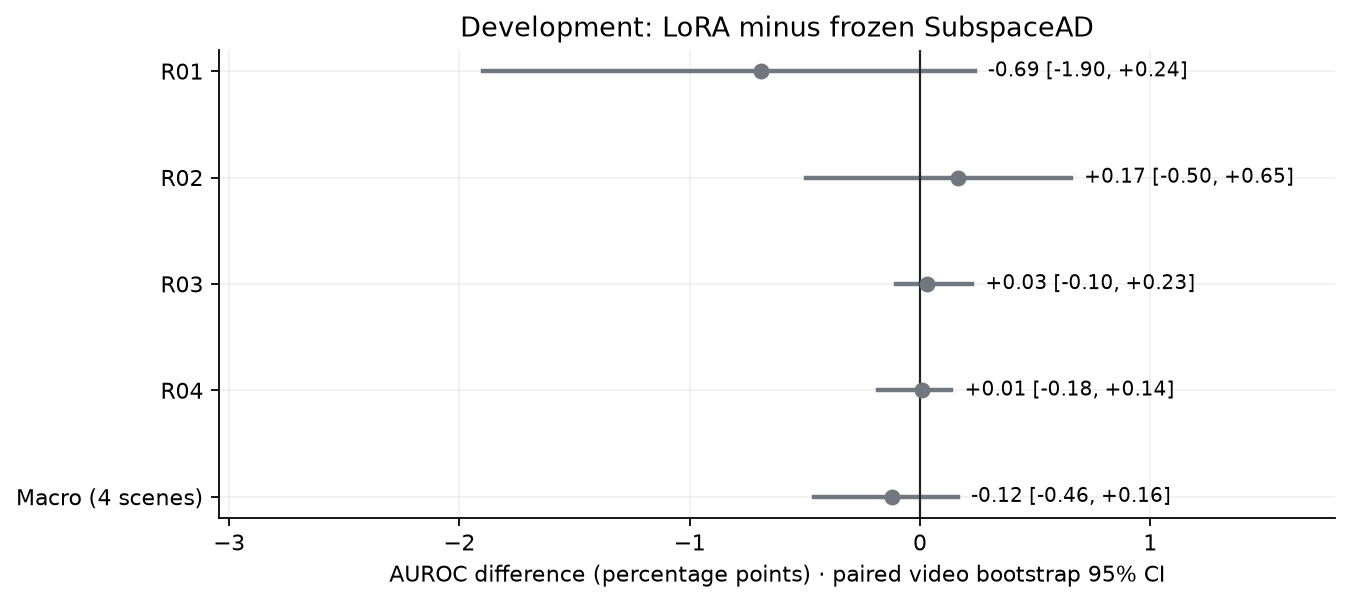

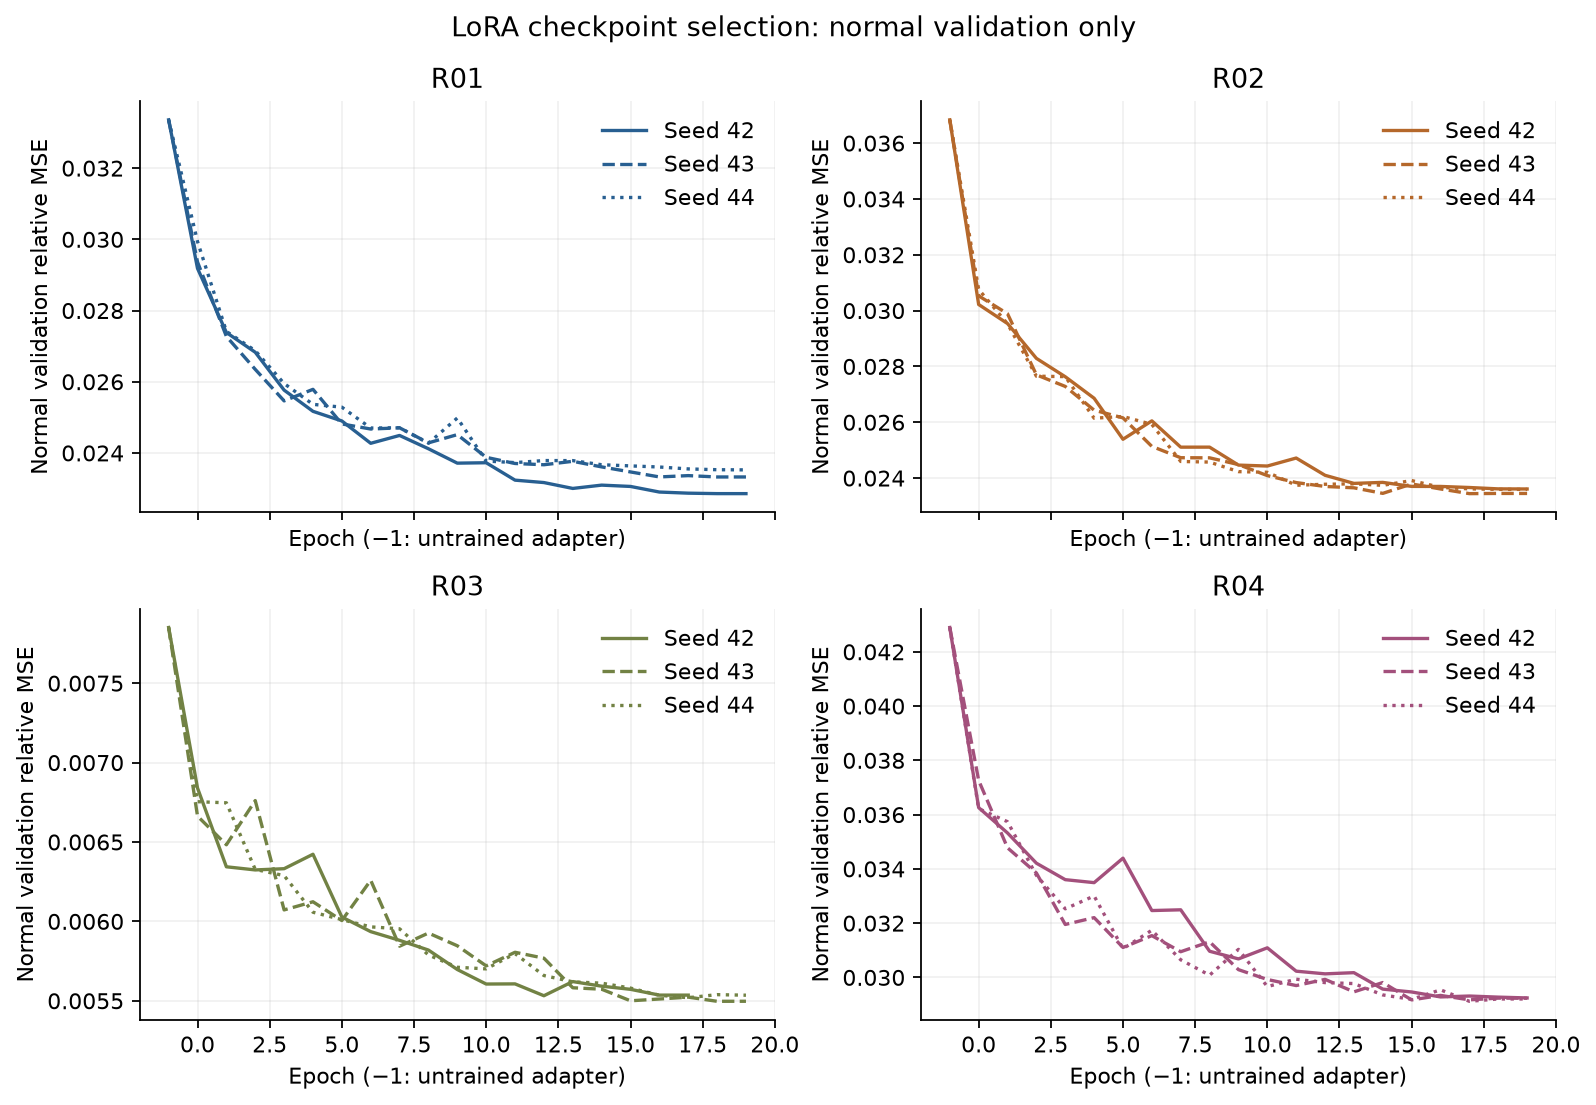

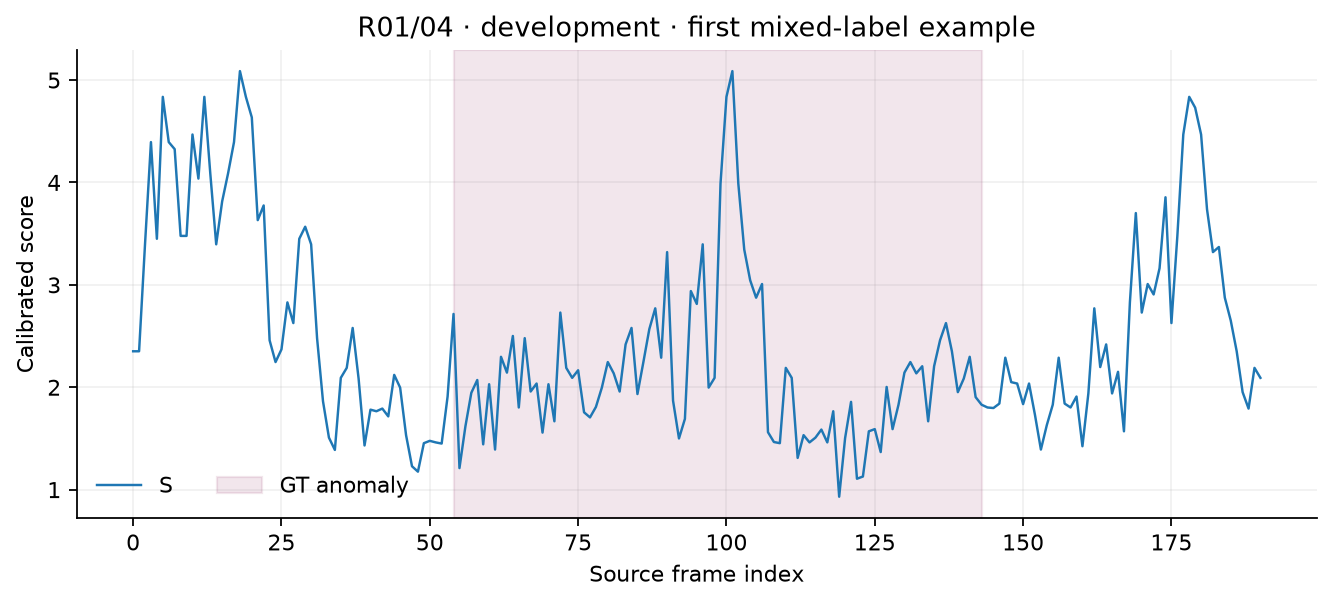

03_ablation


,scene,seed,branch,partition,threshold,auroc,ap,f1,tpr,fpr,frames,positive_frames,events,detected_events,event_coverage,delay_sum,mean_detected_event_delay_frames
0,R01,42,S,final,4.730921,0.607585,0.346917,0.024691,0.013351,0.032075,2339,749,5,3,0.600000,281,93.666667
1,R01,42,S+C,final,4.730921,0.611202,0.348198,0.024691,0.013351,0.032075,2339,749,5,3,0.600000,281,93.666667
2,R01,42,S+P,final,5.087596,0.598164,0.358249,0.036077,0.021362,0.076730,2339,749,5,4,0.800000,101,25.250000
3,R01,42,S+C+P,final,5.087596,0.598190,0.358256,0.036077,0.021362,0.076730,2339,749,5,4,0.800000,101,25.250000
4,R01,42,S+C0,final,4.730921,0.611186,0.348197,0.024691,0.013351,0.032075,2339,749,5,3,0.600000,281,93.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,R04,44,P,final,6.306275,0.684849,0.776765,0.148079,0.081583,0.035478,4568,2905,13,9,0.692308,379,42.111111
140,R04,44,S+C_no_conf,final,13.209203,0.748847,0.778244,0.002055,0.001033,0.006615,4568,2905,13,2,0.153846,73,36.500000
141,R04,44,S+alignment,final,13.199401,0.697149,0.735566,0.001371,0.000688,0.006615,4568,2905,13,1,0.076923,0,0.000000
142,R04,44,S+innovation,final,13.199401,0.726621,0.749074,0.001371,0.000688,0.006615,4568,2905,13,1,0.076923,0,0.000000


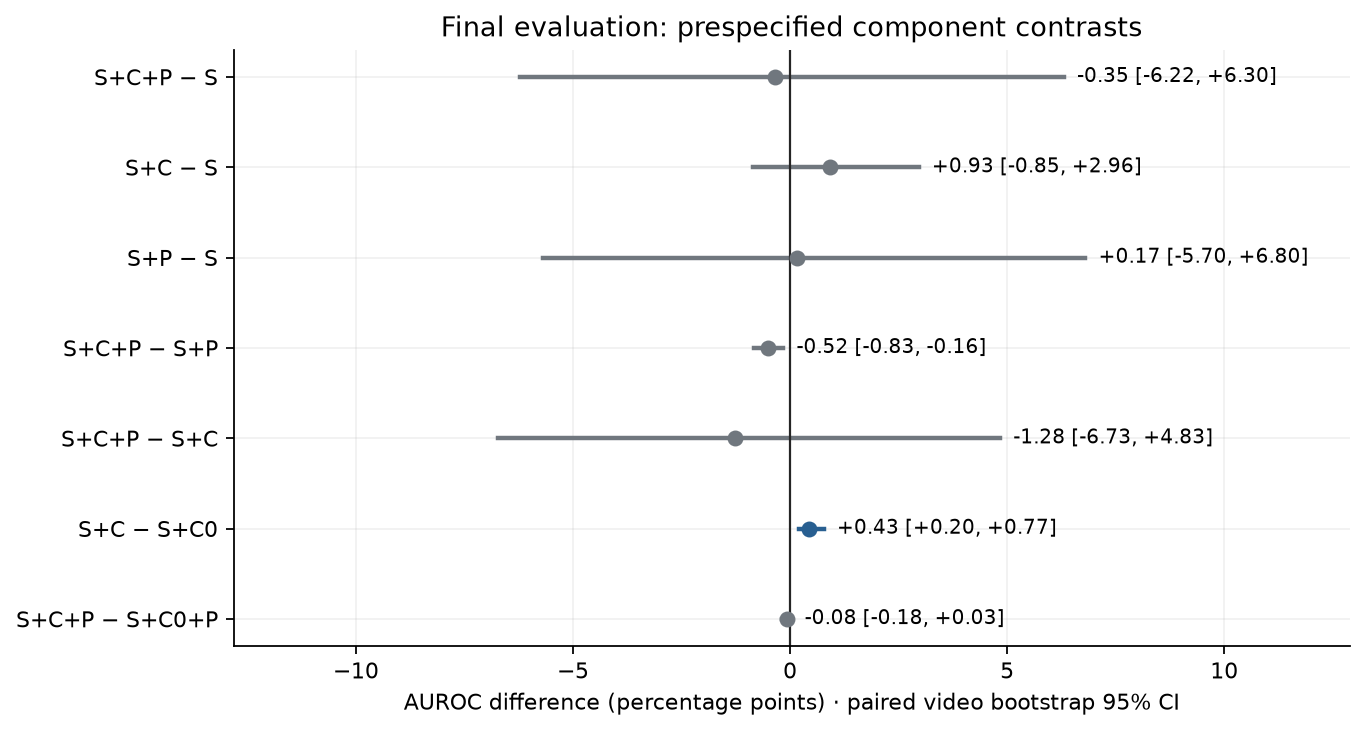

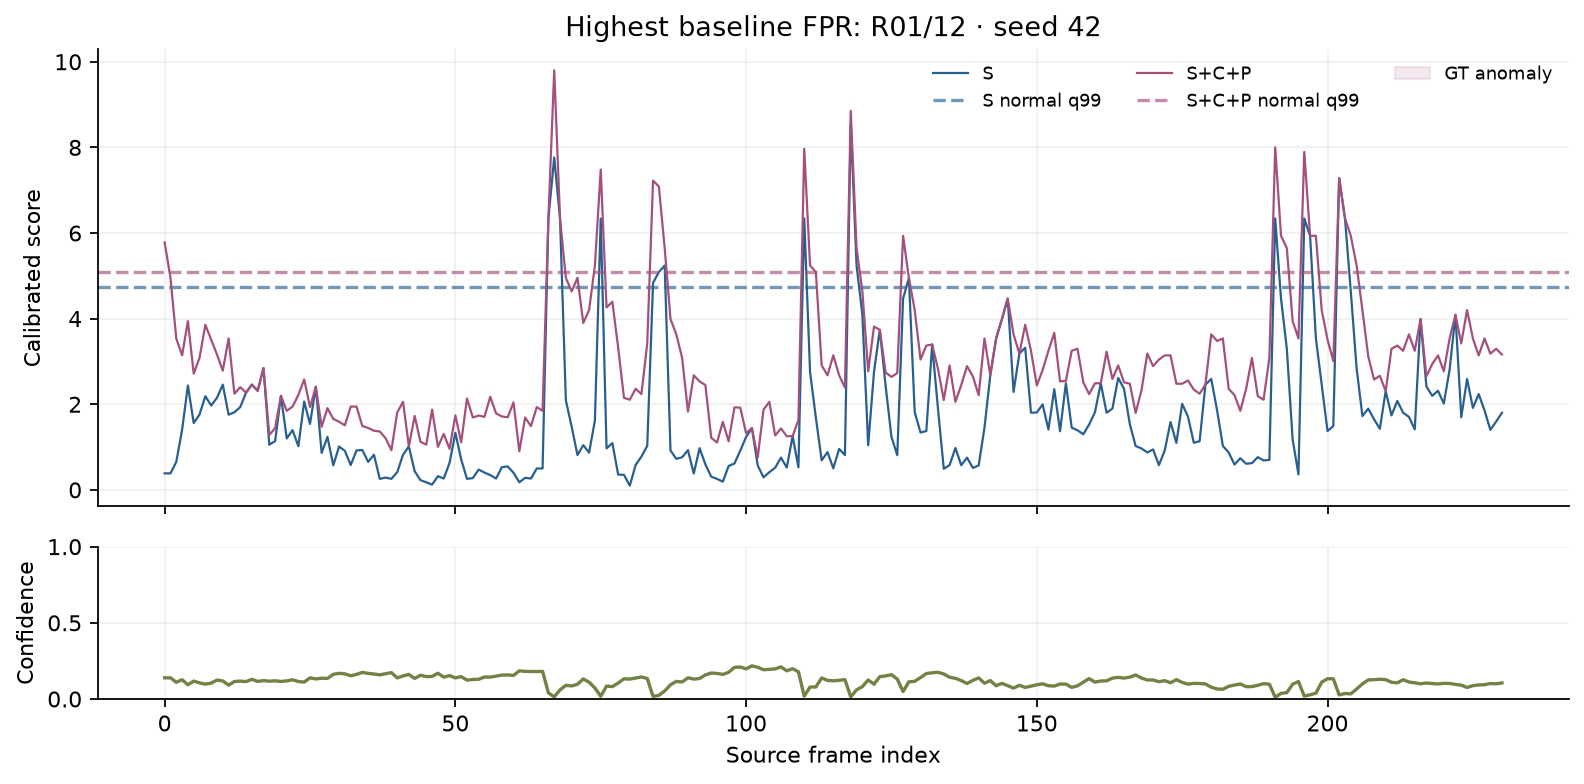

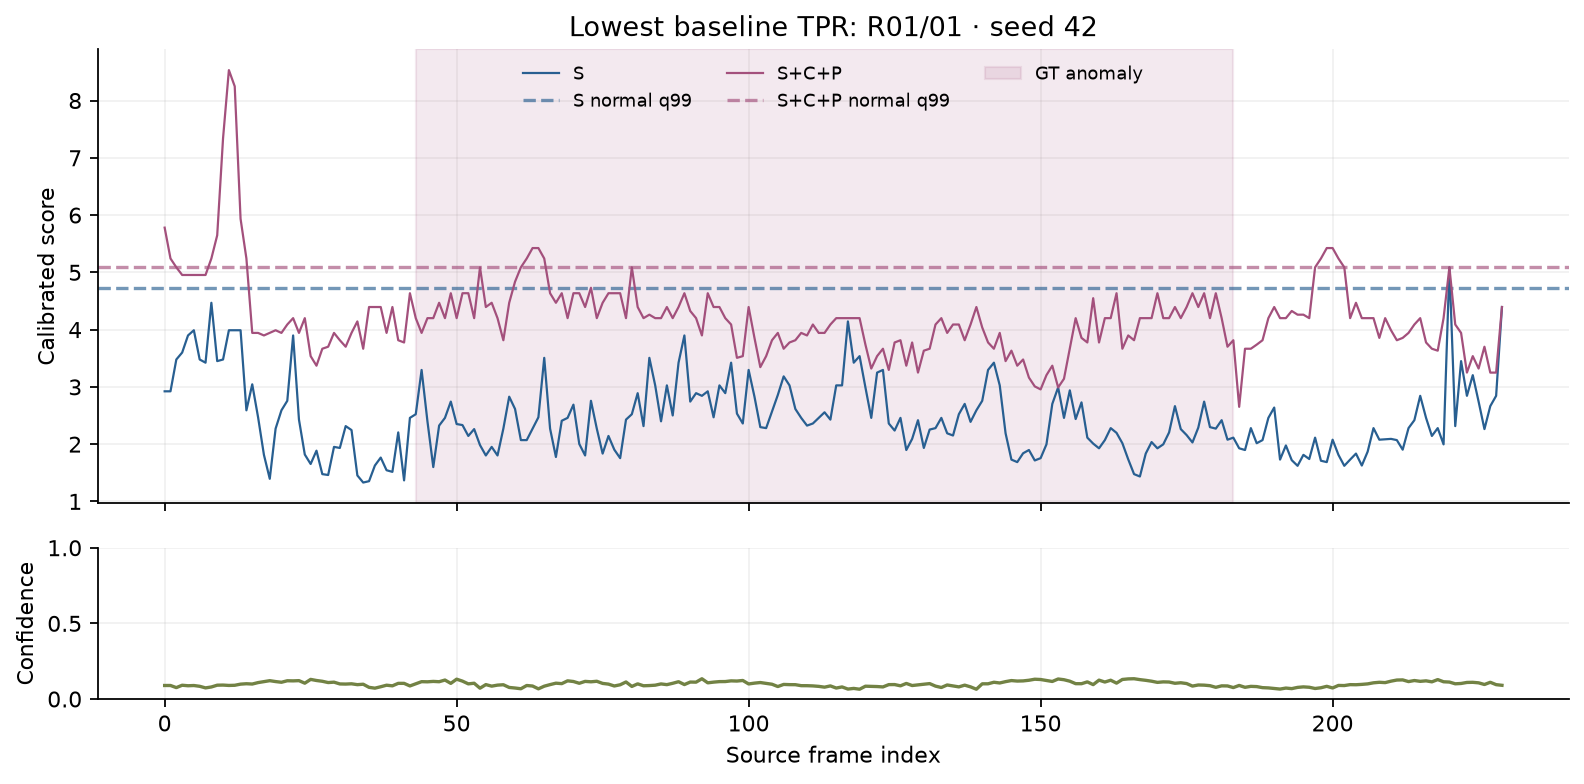

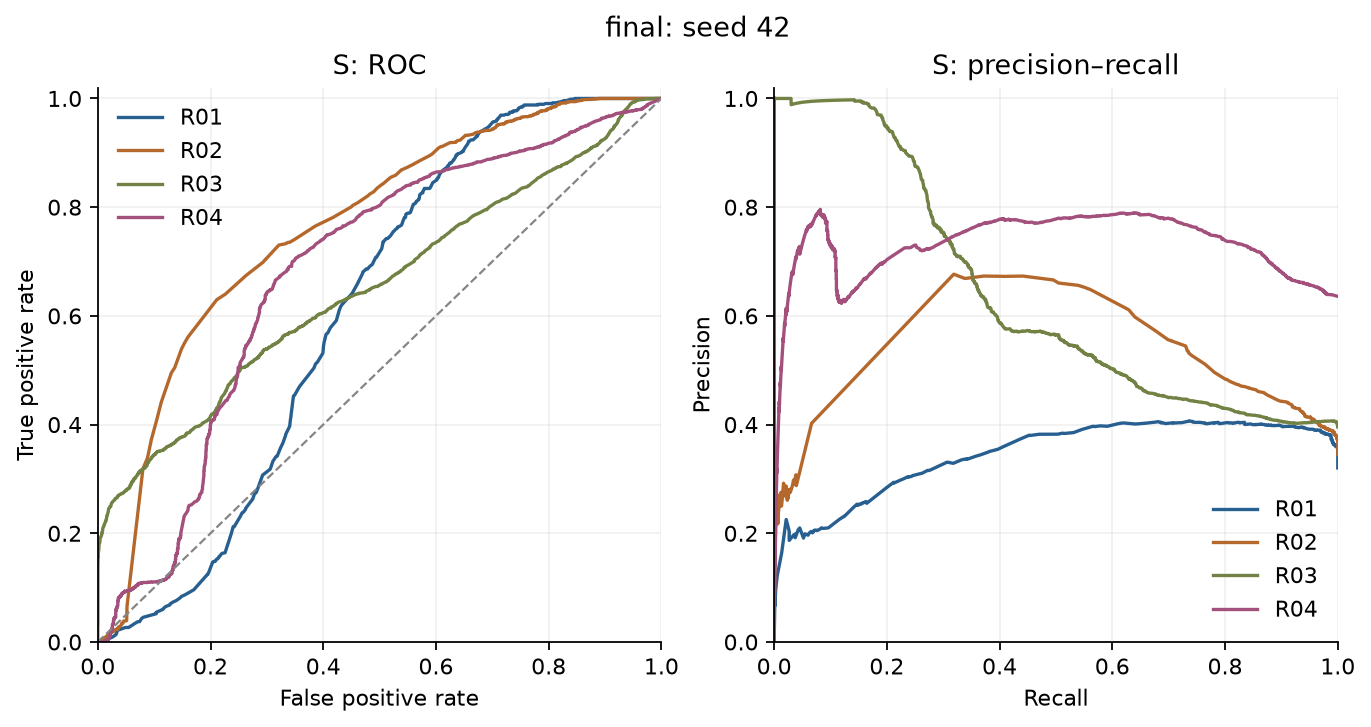

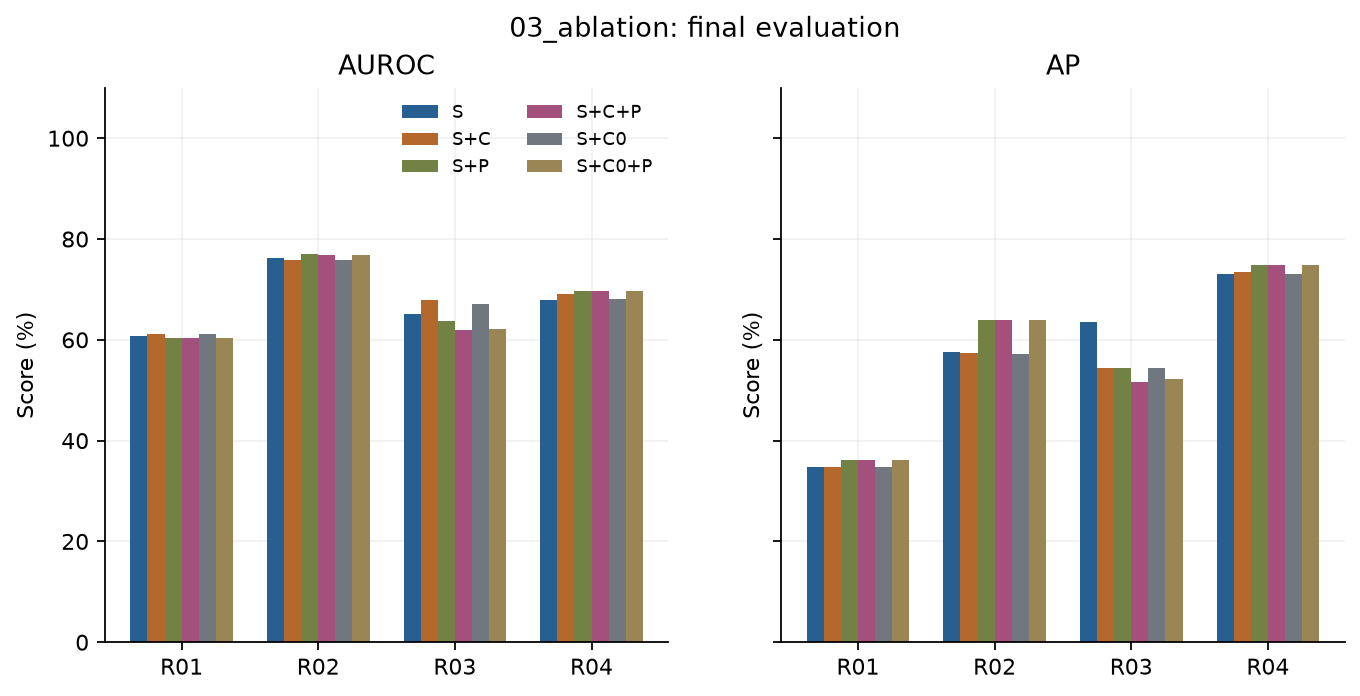

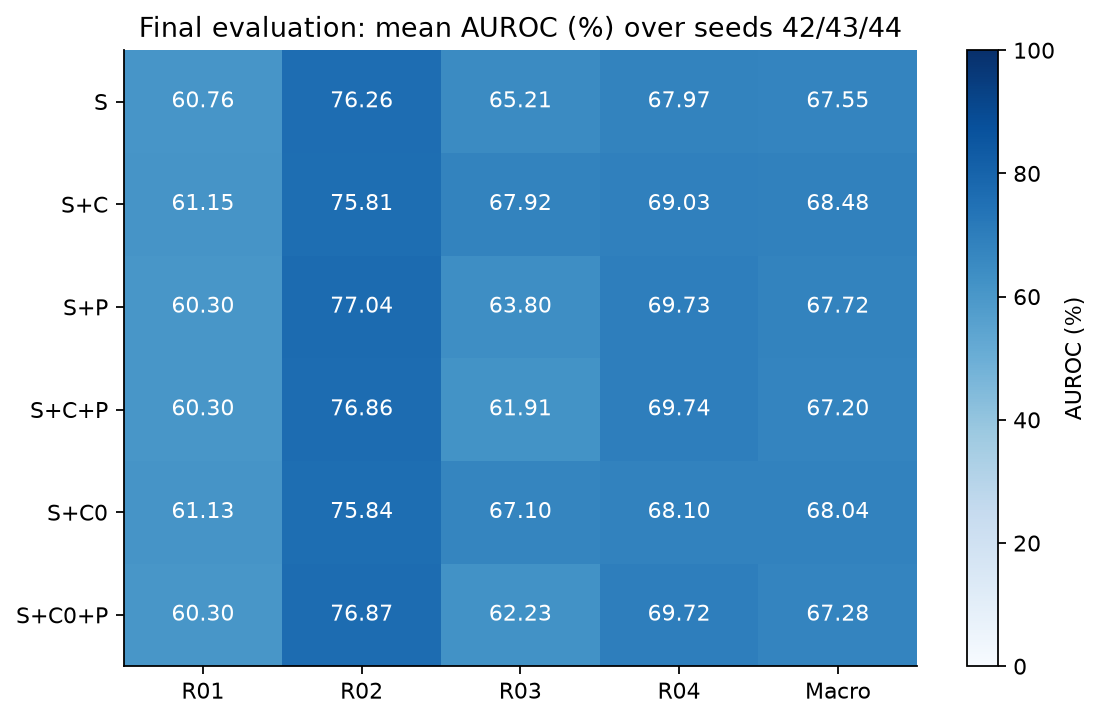

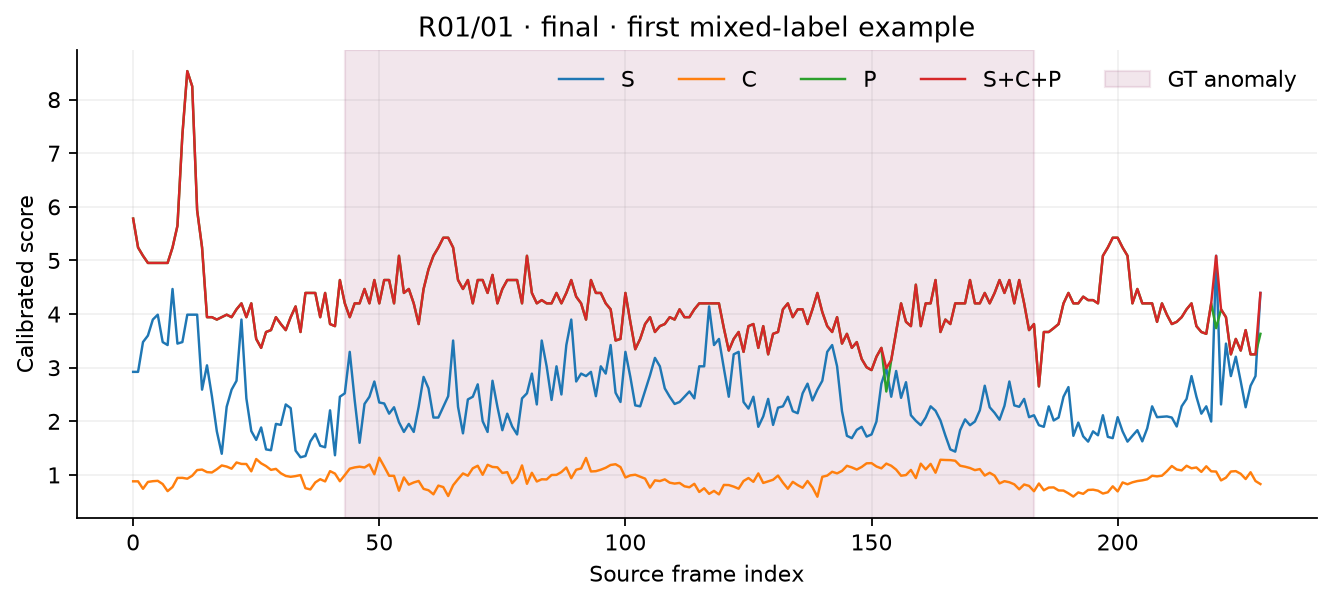

In [3]:
subprocess.run([sys.executable, '-m', 'ipad_experiment.pipeline', 'report'], cwd=ROOT, check=True)
for run in sorted((ROOT/'results').iterdir()):
    if not run.is_dir(): continue
    print(run.name)
    metric = run/'metrics_by_scene.csv'
    if metric.exists(): display(pd.read_csv(metric))
    else: print('No performance metrics for this stage.')
    for figure in sorted((run/'figures').glob('*.png')): display(Image(filename=str(figure)))

## 해석과 한계

각 단계의 report.md와 README는 실행된 로그·지표에서 작성합니다. 추정 cycle 좌표는 실제 위치 정답이 아닙니다. LoRA 채택은 고정된 개발셋 기준으로만 판단합니다.